In [228]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


In [229]:
df1 = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

In [230]:
df1

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy
0,Metformin,7750,4753,Monthly
1,Lisinopril,5136,9965,Quarterly
2,Metformin,3183,2933,Monthly
3,Insulin,2332,3927,Monthly
4,Atorvastatin,3522,6812,Monthly
...,...,...,...,...
99995,Metformin,7635,7794,Weekly
99996,Atorvastatin,8438,7308,Monthly
99997,Metformin,4950,3445,Quarterly
99998,Atorvastatin,4672,5278,Monthly


In [231]:
df1.describe()

,Demand_Forecast,Optimal_Stock_Level
count,100000.000000,100000.000000
mean,5489.372180,6270.155320
std,2597.544993,2744.393068
min,1000.000000,1500.000000
25%,3243.000000,3899.750000
50%,5487.000000,6278.000000
75%,7738.000000,8660.000000
max,9999.000000,10999.000000


In [232]:
df1.shape

(100000, 4)

In [233]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB


In [234]:
df1.columns

Index(['Drug', 'Demand_Forecast', 'Optimal_Stock_Level',
       'Restocking_Strategy'],
      dtype='object')

In [235]:
df1.isnull().sum()

Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64

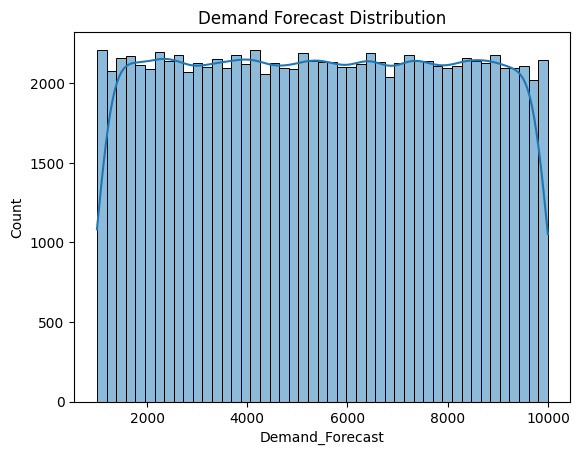

In [236]:
sns.histplot(df1['Demand_Forecast'], kde=True)
plt.title("Demand Forecast Distribution")
plt.show()

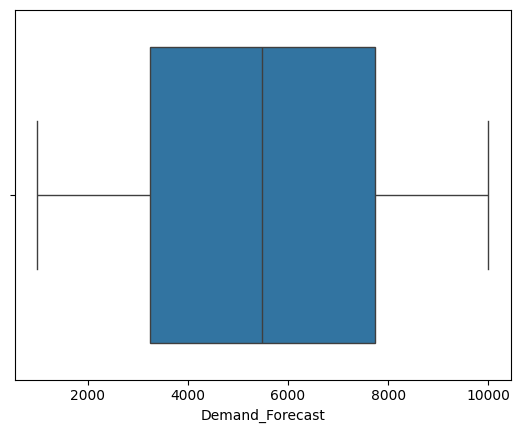

In [237]:
sns.boxplot(x=df1['Demand_Forecast'])
plt.show()

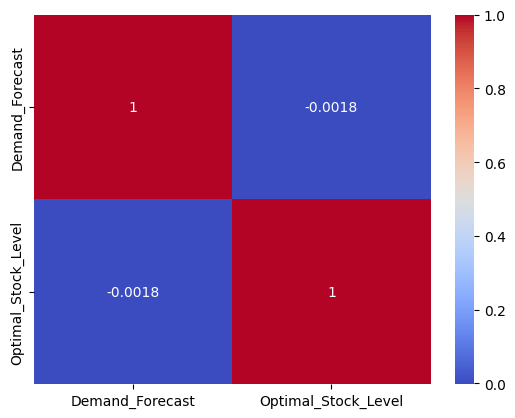

In [238]:
sns.heatmap(df1.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [239]:
df1['Stock_Ratio'] = (df1['Optimal_Stock_Level']/ df1['Demand_Forecast'])

In [240]:
mapping = {'Monthly':12,'Quarterly':4,'Yearly':1}
df1['Restock_Frequency'] = (df1['Restocking_Strategy'].map(mapping))

In [241]:
df1

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Stock_Ratio,Restock_Frequency
0,Metformin,7750,4753,Monthly,0.613290,12.0
1,Lisinopril,5136,9965,Quarterly,1.940226,4.0
2,Metformin,3183,2933,Monthly,0.921458,12.0
3,Insulin,2332,3927,Monthly,1.683962,12.0
4,Atorvastatin,3522,6812,Monthly,1.934128,12.0
...,...,...,...,...,...,...
99995,Metformin,7635,7794,Weekly,1.020825,NaN
99996,Atorvastatin,8438,7308,Monthly,0.866082,12.0
99997,Metformin,4950,3445,Quarterly,0.695960,4.0
99998,Atorvastatin,4672,5278,Monthly,1.129709,12.0


In [242]:
df1.isnull().sum()

Drug                       0
Demand_Forecast            0
Optimal_Stock_Level        0
Restocking_Strategy        0
Stock_Ratio                0
Restock_Frequency      33439
dtype: int64

In [243]:
num_cols = df1.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df1[col].fillna(df1[col].median(), inplace=True)

# Categorical columns
cat_cols = df1.select_dtypes(include=['object']).columns

for col in cat_cols:
    df1[col].fillna(df1[col].mode()[0], inplace=True)

print(df1.isnull().sum())

Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
Stock_Ratio            0
Restock_Frequency      0
dtype: int64


C:\Users\tejal\AppData\Local\Temp\ipykernel_17976\3516306717.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].fillna(df1[col].median(), inplace=True)
C:\Users\tejal\AppData\Local\Temp\ipykernel_17976\3516306717.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [244]:
le_drug = LabelEncoder()
le_Restocking_Strategy = LabelEncoder()

df1["Drug"] = le_drug.fit_transform(df1["Drug"])
df1["Restocking_Strategy"] = le_Restocking_Strategy.fit_transform(df1["Restocking_Strategy"])


In [245]:
df1

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Stock_Ratio,Restock_Frequency
0,3,7750,4753,0,0.613290,12.0
1,2,5136,9965,1,1.940226,4.0
2,3,3183,2933,0,0.921458,12.0
3,1,2332,3927,0,1.683962,12.0
4,0,3522,6812,0,1.934128,12.0
...,...,...,...,...,...,...
99995,3,7635,7794,2,1.020825,4.0
99996,0,8438,7308,0,0.866082,12.0
99997,3,4950,3445,1,0.695960,4.0
99998,0,4672,5278,0,1.129709,12.0


In [246]:
x = df1.drop("Demand_Forecast",axis=1)
y = df1["Demand_Forecast"]

In [247]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [248]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [249]:
y_pred = model.predict(x_test)

In [250]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1385.985267965723
MSE: 2724767.2541083954
RMSE: 1650.6869037186898
R2 Score: 0.5965542317762406


In [251]:
rf_model = Pipeline([
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [252]:
rf_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionc

In [253]:
y_pred = rf_model.predict(x_test)

In [254]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 8.887953999999997
RMSE: 12.561718713615585
R2 Score: 0.9999766356404055


In [255]:
gb_model = Pipeline([
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

In [256]:
gb_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for frac

In [257]:
gb_pred = gb_model.predict(x_test)

In [258]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

Gradient Boosting Results
MAE : 157.86286398697132
RMSE: 215.4730103920693
R2 Score: 0.9931254937418903


In [261]:
rf_pipeline = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

In [262]:
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [263]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [265]:

y_pred = rf_model.predict(x_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Final Model RMSE:", rmse)

Final Model RMSE: 12.561718713615585


In [266]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("Cross Validation RMSE Scores:")
print(cv_rmse)

print("\nAverage CV RMSE:")
print(cv_rmse.mean())

Cross Validation RMSE Scores:
[12.71057635 12.97931443 13.2285377  12.8539196  13.18004634]

Average CV RMSE:
12.990478882746379


In [267]:
cv_r2 = cross_val_score(
    rf_model,
    x,
    y,
    cv=5,
    scoring="r2"
)

print("R² Scores:", cv_r2)
print("Average R²:", cv_r2.mean())

R² Scores: [0.99997627 0.99997507 0.99997395 0.99997545 0.99997415]
Average R²: 0.9999749790751278


In [268]:
results = pd.DataFrame({
    "Metric": ["Test RMSE", "Average CV RMSE"],
    "Value": [rmse, cv_rmse.mean()]
})

print(results)

            Metric      Value
0        Test RMSE  12.561719
1  Average CV RMSE  12.990479
